<a href="https://colab.research.google.com/github/danielesilva8/DataScience/blob/master/melhorecompras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importação das Bibliotecas

In [1]:
# Importação das bibliotecas essenciais

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuração visual para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

2. Carga dos Dados e Aplicação de Regras de Negócio

In [3]:
# Carregando o dataset

df = pd.read_csv('sales.csv')

In [4]:
# Visualizando as primeiras linhas antes das transformações

print("Dados originais:")
display(df.head())

Dados originais:


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,05-02-2010,1643690.90,0,42.31,2572.0,211.096358,8106
1,12-02-2010,1641957.44,1,38.51,2548.0,211.242170,8106
2,19-02-2010,1611968.17,0,39.93,2514.0,211.289143,8106
3,26-02-2010,1409727.59,0,46.63,2561.0,211.319643,8106
4,05-03-2010,1554806.68,0,46.50,2625.0,211.350143,8106


In [7]:
# 1. Tratamento de Datas (Feature Engineering)
# Convertendo a coluna 'Date' para o formato datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [8]:
# Criando novas colunas para Mês e Ano
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [9]:
# 2. Aplicação das Regras de Negócio
# Dividindo Fuel_Price e Unemployment por 1000 conforme o dicionário de dados
df['Fuel_Price'] = df['Fuel_Price'] / 1000
df['Unemployment'] = df['Unemployment'] / 1000

print("\nDados após transformações:")
display(df.head())


Dados após transformações:


,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


3. Análise Exploratória (EDA)

In [10]:
# Selecionando apenas as colunas numéricas para a matriz de correlação
cols_numericas = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
matriz_correlacao = df[cols_numericas].corr()

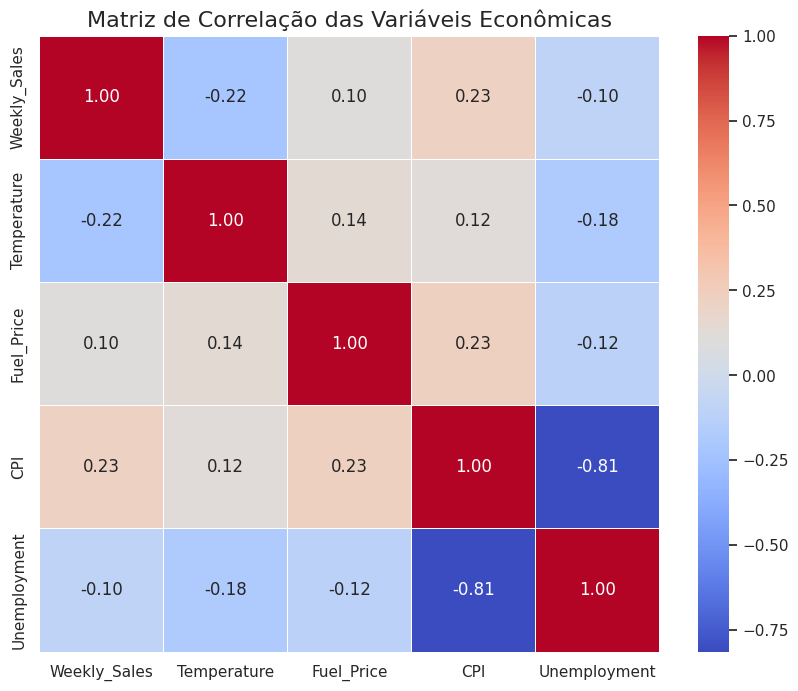

In [11]:
# Plotando o Heatmap de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Econômicas', fontsize=16)
plt.show()

Impacto dos Feriados nas Vendas:

/tmp/ipykernel_1411/2227318663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette='Set2')


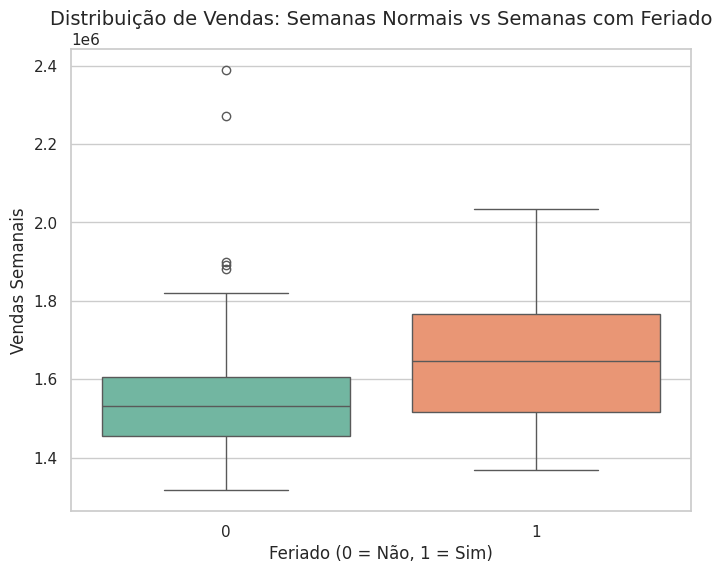

In [12]:
# Boxplot comparando as vendas em semanas com e sem feriado
plt.figure(figsize=(8, 6))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette='Set2')
plt.title('Distribuição de Vendas: Semanas Normais vs Semanas com Feriado', fontsize=14)
plt.xlabel('Feriado (0 = Não, 1 = Sim)')
plt.ylabel('Vendas Semanais')
plt.show()

Comportamento Histórico das Vendas

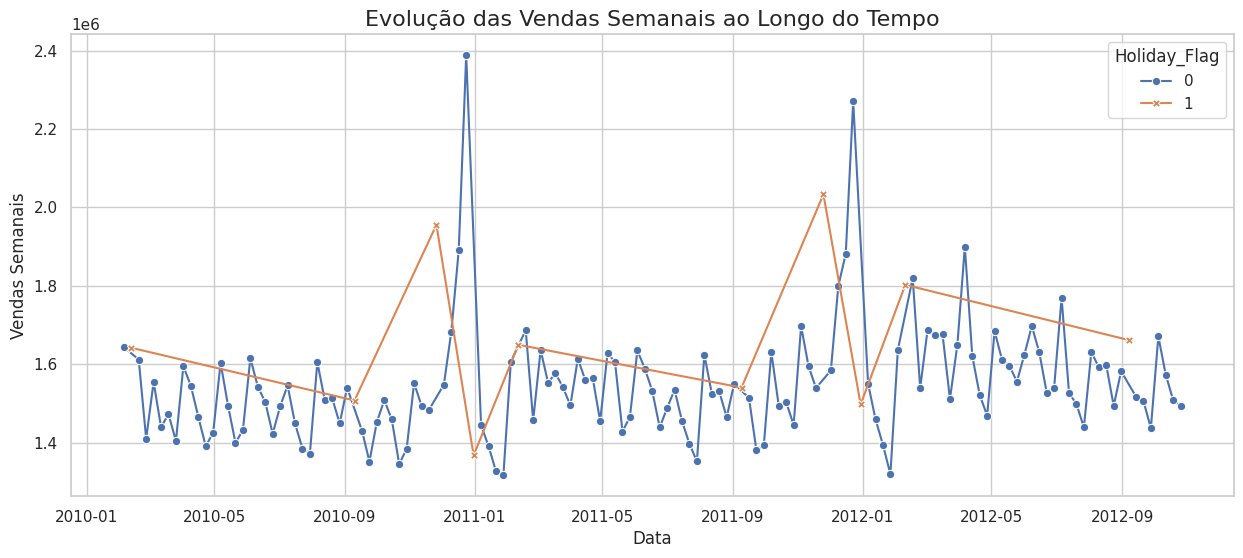

In [13]:
# Gráfico de linha para ver a tendência de vendas ao longo do tempo
plt.figure(figsize=(15, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=df, hue='Holiday_Flag', style='Holiday_Flag', markers=True, dashes=False)
plt.title('Evolução das Vendas Semanais ao Longo do Tempo', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Vendas Semanais')
plt.show()

1. Separação dos Dados (Train/Test Split)

In [15]:
# Importação dos módulos de Machine Learning do scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Definindo as variáveis preditoras (X) e a variável alvo (y)
# Removemos 'Date' por ser datetime, e 'Weekly_Sales' porque é o que queremos prever
X = df.drop(columns=['Date', 'Weekly_Sales'])
y = df['Weekly_Sales']

# 2. Separando os dados: 80% para o modelo aprender, 20% para testarmos a precisão
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do treino: {X_train.shape[0]} linhas")
print(f"Tamanho do teste: {X_test.shape[0]} linhas")

Tamanho do treino: 114 linhas
Tamanho do teste: 29 linhas


2. Treinamento: Regressão Linear (Baseline)

In [16]:
# Instanciando e treinando o modelo linear
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Fazendo as previsões com os dados de teste
previsoes_lr = modelo_lr.predict(X_test)

# Calculando as métricas de erro
mae_lr = mean_absolute_error(y_test, previsoes_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, previsoes_lr))
r2_lr = r2_score(y_test, previsoes_lr)

print("--- Performance da Regressão Linear ---")
print(f"MAE (Erro Absoluto Médio): {mae_lr:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_lr:.2f}")
print(f"R² (Coeficiente de Determinação): {r2_lr:.4f}")

--- Performance da Regressão Linear ---
MAE (Erro Absoluto Médio): 111401.65
RMSE (Raiz do Erro Quadrático Médio): 144703.75
R² (Coeficiente de Determinação): 0.1343


3. Treinamento: Random Forest (Modelo Robusto)

In [17]:
# Instanciando e treinando o Random Forest com 100 árvores
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Fazendo as previsões
previsoes_rf = modelo_rf.predict(X_test)

# Calculando as métricas
mae_rf = mean_absolute_error(y_test, previsoes_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, previsoes_rf))
r2_rf = r2_score(y_test, previsoes_rf)

print("--- Performance do Random Forest ---")
print(f"MAE (Erro Absoluto Médio): {mae_rf:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_rf:.2f}")
print(f"R² (Coeficiente de Determinação): {r2_rf:.4f}")

--- Performance do Random Forest ---
MAE (Erro Absoluto Médio): 100515.92
RMSE (Raiz do Erro Quadrático Médio): 126951.74
R² (Coeficiente de Determinação): 0.3337


4. O "Pulo do Gato"

/tmp/ipykernel_1411/96708558.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=importancias, palette='viridis')


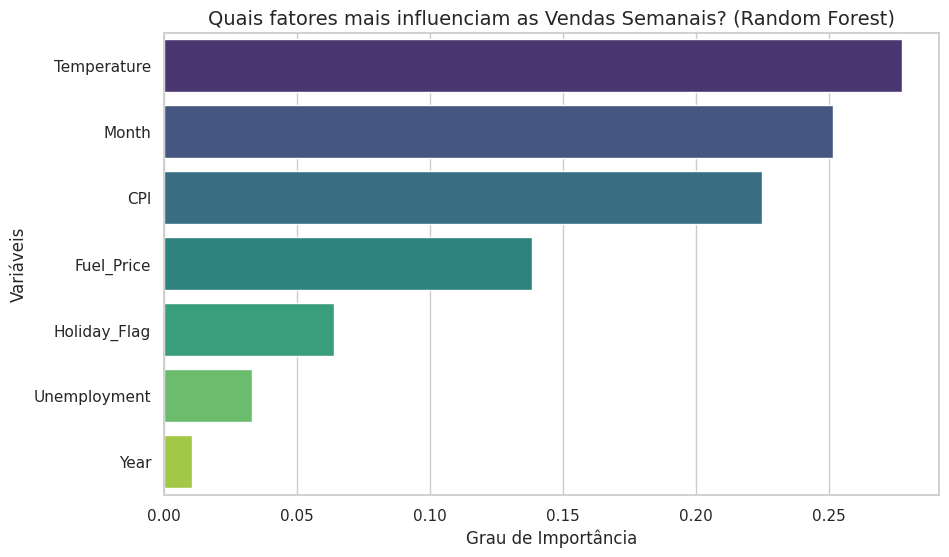

In [18]:
# Extraindo a importância de cada variável
importancias = pd.DataFrame({
    'Variável': X_train.columns,
    'Importância': modelo_rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

# Plotando o gráfico de Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importancias, palette='viridis')
plt.title('Quais fatores mais influenciam as Vendas Semanais? (Random Forest)', fontsize=14)
plt.xlabel('Grau de Importância')
plt.ylabel('Variáveis')
plt.show()

Gerar o arquivo final no Colab

In [19]:
# 1. Usar o modelo treinado (modelo_rf) para prever as vendas de toda a base (X)
df['Previsao_Vendas'] = modelo_rf.predict(X)

# 2. Criar uma tabela separada para a Importância das Variáveis
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# 3. Exportar tudo para CSV
df.to_csv('base_com_previsoes.csv', index=False)
importancias.to_csv('importancia_variaveis.csv', index=False)

print("Arquivos exportados com sucesso! Verifique a pasta lateral do Colab.")

Arquivos exportados com sucesso! Verifique a pasta lateral do Colab.
